## 1.Code Description

**What is MNIST data?**

MNIST is a dataset consisting of 60,000+ images of handwritten digits for training and another 10,000 for testing. Each training example comes with an associated label (0 to 9) indicating what digit it is. Each digit will be a black and white image of 28 X 28 pixels.

**Architecture of CNN**

A convolutional neural network is different from a standard artificial neural network, and may involve convolutional, pooling, fully connected and softmax layers

# Tensorflow implementation

**Note:** Below code from step 1 to 12 is just for explanation, full code for execution is available in second section.

**STEP 1:** Importing Tensorflow and important libraries


In [ ]:
#!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")



**STEP 2:** Importing the dataset.

In [40]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

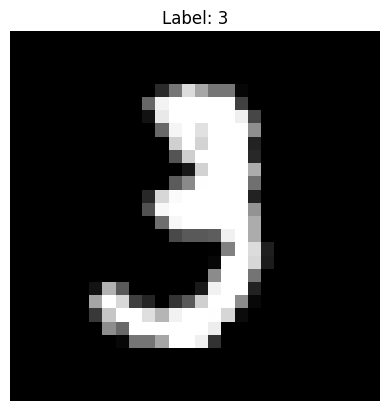

In [4]:
# plotting the dataset
plt.imshow(x_train[10], cmap='gray')
plt.title(f'Label: {y_train[10]}')
plt.axis('off')
plt.show()

**STEP 3:** Split the dataset into train and test and reshape them.

In [41]:
x_train, x_test = x_train / 255.0, x_test / 255.0 # normalizing the data
# Reshaping the data to fit the model
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
# Converting labels to categorical format
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [42]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28, 1), (60000, 10), (10000, 28, 28, 1), (10000, 10))

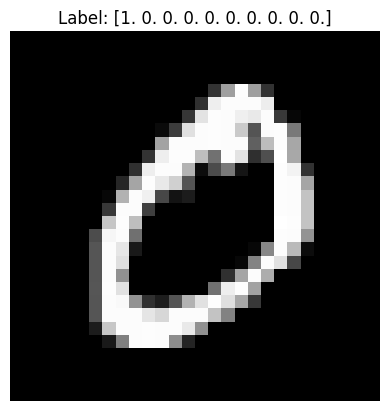

In [43]:
# lets check the x_train and x_test shapes sample with image and label
plt.imshow(x_train[1], cmap='gray')
plt.title(f'Label: {y_train[1]}')
plt.axis('off')
plt.show()

**STEP 4:** Create and compile the model



**STEP 4.1:** Create Sequential Layer as first layer as Input layer

In [44]:
model = models.Sequential()

**STEP 4.2:** Convolutional layers

Convolutional layer is generally the first layer of a CNN. It calculates the element wise product of the image matrix, and a filter. In the above example, the image is a 28 X 28 matrix and the filter going over it is a 3 x 3 matrix. A convolution operation takes place between the image and the filter and the convolved feature is generated. The convoluted feature shown in the gif is the output of a convolutional layer.

The function defined below will take the feature vector and weight vector as input and add a convolutional layer to our tensorflow model accordingly.


In [ ]:
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))#First conv layer
model.add(layers.Conv2D(64, (3, 3), activation='relu')) # Second conv layer
model.add(layers.Conv2D(64, (3, 3), activation='relu')) # Third conv layer

**STEP 4.3:** Pooling layer

Pooling layers are generally added after a convolutional layer, to reduce the dimensions of our data. A pooling window size is selected, and all the values in there will be replaced by the maximum, average or some other value. Max Pooling, one of the most common pooling techniques, may be demonstrated as follows:
The following function is a maxpool function, taking the feature vector as input and adding a max-pooling layer to our model. The window size and strides are defined as shown

In [45]:
model.add(layers.MaxPooling2D((2, 2)))

**STEP 4.4:** Fully connected layer

Now that our convolutional and pooling layers have reduced complexity of the data, we can use a regular fully connected layer in order to determine the true relation that our parameters have on labels. In order to classify the images as one label from 0 to 9, such a layer is needed. The data is flattenned to make it linear. These layers generally use the RELU activation function.


In [46]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

**STEP 4.5:** Softmax output layer

Softmax is an output layer function which is used for multi-class classification problems. As we need an output layer which can classify a digit as either from 0 to 9, softmax function can be used to classify it to either of the 10 classes.


In [47]:
# Here we make use of a Softmax function and compare the result with the y label.
model.add(layers.Dense(10, activation='softmax'))

**STEP 5:** Compile the model


In [50]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

**STEP 6:** Train the model with early stopping.<br>
We train the model with early stopping to prevent overfitting and to find the optimal point during the training process where the model performs well on both the training and validation data.

In [51]:
early_stopping = EarlyStopping(patience=3, restore_best_weights=True)
model.fit(x_train, y_train, epochs = 10, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7849 - loss: 0.7627 - val_accuracy: 0.9256 - val_loss: 0.2544
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9257 - loss: 0.2516 - val_accuracy: 0.9407 - val_loss: 0.1981
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9420 - loss: 0.1948 - val_accuracy: 0.9464 - val_loss: 0.1741
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9509 - loss: 0.1624 - val_accuracy: 0.9516 - val_loss: 0.1536
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9581 - loss: 0.1375 - val_accuracy: 0.9556 - val_loss: 0.1460
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9632 - loss: 0.1218 - val_accuracy: 0.9573 - val_loss: 0.1322
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9648 - loss: 0.1124 - val_accuracy: 0.9602 - val_loss: 0.1281
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9696 - loss: 0.1014 - 

**STEP 7:** Evaluating model accuracy on test data and update best parameters if accuracy is improved

In [53]:
accuracy = model.evaluate(x_test, y_test, verbose=0)[1]
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.9674


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted label for the sample image: 4


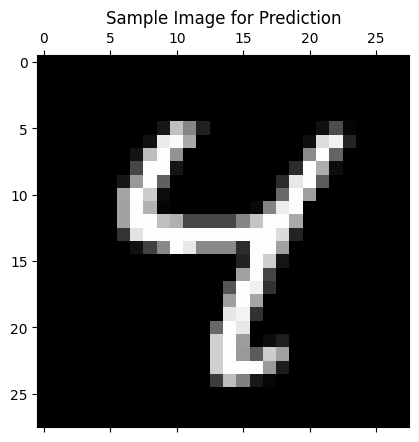

In [56]:
# test the model with a sample image
import numpy as np
sample_image = x_test[6]  # Take the first image from the test set
sample_image = np.expand_dims(sample_image, axis=0)  # Add batch dimension
plt.matshow(sample_image[0].reshape(28, 28), cmap='gray')
plt.title('Sample Image for Prediction')


predicted_label = model.predict(sample_image)
predicted_label = np.argmax(predicted_label, axis=1)  # Get the index of the highest probability
print(f'Predicted label for the sample image: {predicted_label[0]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


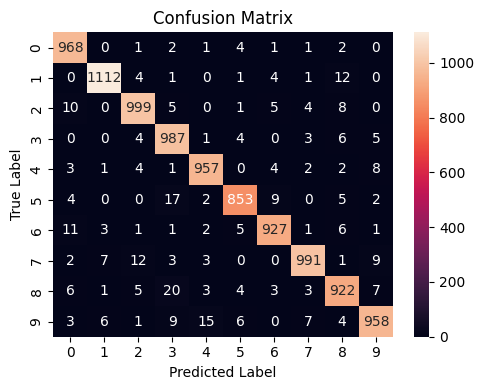

In [61]:
# Confusing matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
conf_matrix = confusion_matrix(np.argmax(y_test, axis=1), y_pred_classes)
plt.figure(figsize=(5, 4))

ax = sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=range(10), yticklabels=range(10))
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted Label')  # Set X-axis label
ax.set_ylabel('True Label')       # Set Y-axis label
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()  # Display the plot